# Grad-CAM — Which pixels drove the prediction?

Interactive Grad-CAM for **`/home/david/coin/weights/emp_model_distil_student.pth`**, the MobileNetV3-Large
distilled from the v6 ensemble teacher (92.71% test acc). This is a notebook version
of `gradcam.py` in this folder — same math, but inline plots and a browser widget
so you can click through coins instead of running the CLI per-image.

For each image we backprop the predicted (or a chosen) class's logit into the last
conv block's activations (`model.features[-1]`, 960 channels) and overlay the
resulting heatmap on the coin.

Run all cells top to bottom, then use the widget at the bottom to browse any coin
in `FOR_TRAINNING/`.

In [1]:
import re
import sys
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as tvm
import torchvision.transforms as T
from PIL import Image
from matplotlib import cm
import matplotlib.pyplot as plt

CHECKPOINT = Path('/home/david/coin/weights/emp_model_distil_student.pth')
DATA_DIR = Path('/home/david/coin/FOR_TRAINNING')

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# Must stay in sync with MERGES in prepare.py / predict.py / gradcam.py.
MERGES = {'GORDIAN II': 'GORDIAN I'}

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda:0


In [2]:
def build_label_names(data_dir: Path, num_classes: int):
    unique_labels = sorted({
        re.sub(r'^\d+_', '', p.name)
        for p in data_dir.iterdir()
        if p.is_dir() and (p / 'side_a').exists()
    })
    if num_classes == len(unique_labels) - len(MERGES):
        kept = [n for n in unique_labels if n not in MERGES]
        return {i: n for i, n in enumerate(kept)}
    return {i: n for i, n in enumerate(unique_labels)}


state = torch.load(CHECKPOINT, map_location=device)
num_classes = state['classifier.3.weight'].shape[0]
idx_to_name = build_label_names(DATA_DIR, num_classes)
name_to_idx = {v: k for k, v in idx_to_name.items()}
print(f'{num_classes} classes loaded, e.g. {list(idx_to_name.values())[:5]}')

51 classes loaded, e.g. ['AEMILIAN', 'ANTONINUS PIUS', 'AUGUSTUS', 'AURELIAN', 'BALBINUS']


In [3]:
def load_student(checkpoint: Path, num_classes: int, device: torch.device) -> nn.Module:
    model = tvm.mobilenet_v3_large(weights=None)
    in_features = model.classifier[3].in_features
    model.classifier[3] = nn.Linear(in_features, num_classes)
    model.load_state_dict(torch.load(checkpoint, map_location=device))
    model.to(device).eval()
    return model


model = load_student(CHECKPOINT, num_classes, device)
total_params = sum(p.numel() for p in model.parameters())
print(f'MobileNetV3-Large loaded: {total_params / 1e6:.1f}M params')

MobileNetV3-Large loaded: 4.3M params


In [4]:
class GradCAM:
    # Hooked on MobileNetV3's last conv block (model.features[-1], 960 channels).

    def __init__(self, model: nn.Module):
        self.model = model
        self.activations = None
        self.gradients = None
        target_layer = model.features[-1]
        target_layer.register_forward_hook(self._save_activations)
        target_layer.register_full_backward_hook(self._save_gradients)

    def _save_activations(self, module, inp, out):
        self.activations = out.detach()

    def _save_gradients(self, module, grad_in, grad_out):
        self.gradients = grad_out[0].detach()

    def __call__(self, img_tensor: torch.Tensor, class_idx: int = None):
        self.model.zero_grad(set_to_none=True)
        logits = self.model(img_tensor)
        probs = torch.softmax(logits, dim=1)
        if class_idx is None:
            class_idx = int(logits.argmax(dim=1).item())
        logits[0, class_idx].backward()

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = F.relu((weights * self.activations).sum(dim=1, keepdim=True))
        cam = F.interpolate(cam, size=img_tensor.shape[-2:], mode='bilinear', align_corners=False)
        cam = cam.squeeze().cpu().numpy()
        cam -= cam.min()
        cam /= (cam.max() + 1e-8)
        return cam, class_idx, probs.squeeze(0).detach().cpu().numpy()


cam_engine = GradCAM(model)

preprocess = T.Compose([
    T.Resize(256),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])
display_crop = T.Compose([T.Resize(256), T.CenterCrop(224)])

In [5]:
def overlay_heatmap(pil_img: Image.Image, cam: np.ndarray, alpha: float = 0.45) -> Image.Image:
    heatmap = (cm.jet(cam)[:, :, :3] * 255).astype(np.uint8)
    heatmap_img = Image.fromarray(heatmap).resize(pil_img.size, Image.BILINEAR)
    base = np.asarray(pil_img).astype(np.float32)
    heat = np.asarray(heatmap_img).astype(np.float32)
    blended = (1 - alpha) * base + alpha * heat
    return Image.fromarray(blended.clip(0, 255).astype(np.uint8))


def visualize(image_path, target_class: str = None, alpha: float = 0.45, topk: int = 3):
    # Shows original | raw heatmap | overlay, plus the model's top-k guesses.
    # target_class: force the CAM to explain a specific emperor's logit instead of
    # the model's own top prediction (useful for a class it got wrong).
    image_path = Path(image_path)
    pil_img = Image.open(image_path).convert('RGB')
    img_tensor = preprocess(pil_img).unsqueeze(0).to(device)

    target_idx = name_to_idx[target_class.strip().upper()] if target_class else None
    cam, used_idx, probs = cam_engine(img_tensor, class_idx=target_idx)
    cropped = display_crop(pil_img)
    overlay = overlay_heatmap(cropped, cam, alpha)

    fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
    axes[0].imshow(cropped); axes[0].set_title('Original (224x224 crop)'); axes[0].axis('off')
    axes[1].imshow(cam, cmap='jet'); axes[1].set_title('Grad-CAM (raw)'); axes[1].axis('off')
    axes[2].imshow(overlay); axes[2].set_title('Overlay'); axes[2].axis('off')

    label = 'Explaining' if target_class else 'Predicted'
    fig.suptitle(f'{image_path.name}  —  {label}: {idx_to_name[used_idx]} (p={probs[used_idx]:.3f})',
                 fontsize=12)
    fig.tight_layout()
    plt.show()

    top_idx = probs.argsort()[::-1][:topk]
    print('Top predictions:')
    for i in top_idx:
        marker = ' <-- explained' if i == used_idx else ''
        print(f'  {idx_to_name[i]:<22s} {probs[i]:.3f}{marker}')

## Try it on one coin

Swap the path for any image under `FOR_TRAINNING/<emperor>/side_a/`.

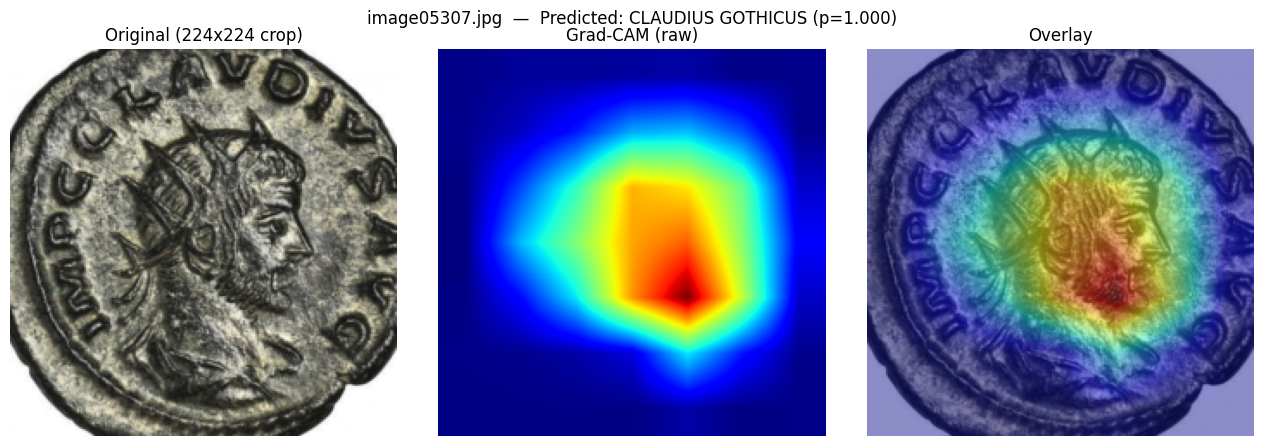

Top predictions:
  CLAUDIUS GOTHICUS      1.000 <-- explained
  PROBUS                 0.000
  TACITUS                0.000


In [6]:
sample = next((DATA_DIR / '40_CLAUDIUS GOTHICUS' / 'side_a').glob('*.jpg'))
visualize(sample)

## Known hard cases

`improvement_or_not.md` flags a few emperor pairs the whole project struggled to
separate (QUINTILLUS/AURELIAN, VALERIAN/AEMILIAN/GALLIENUS, SEPTIMUS SEVERUS/DIDIUS
JULIANUS). Let's see what the model is looking at on those.

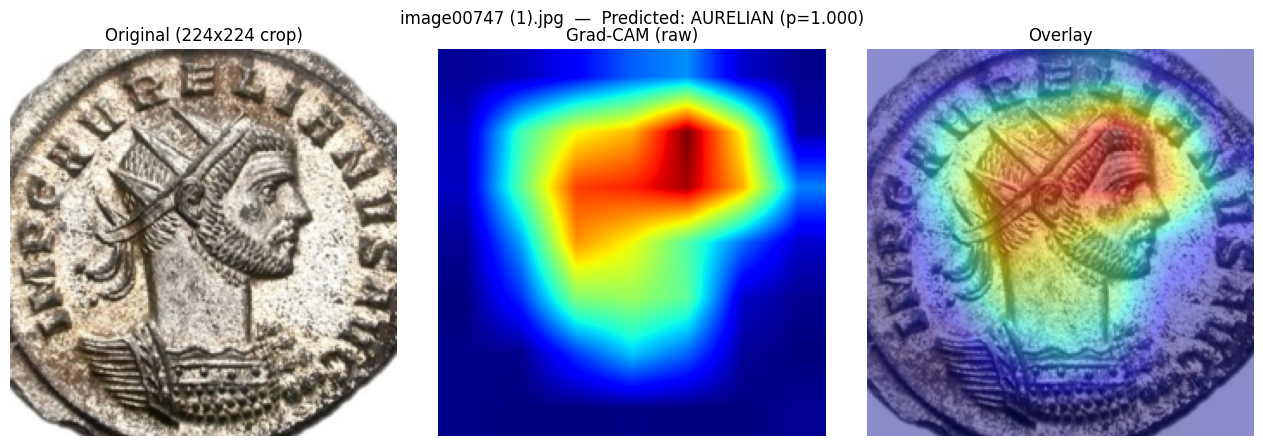

Top predictions:
  AURELIAN               1.000 <-- explained
  QUINTILLUS             0.000
  DIOCLETIAN             0.000


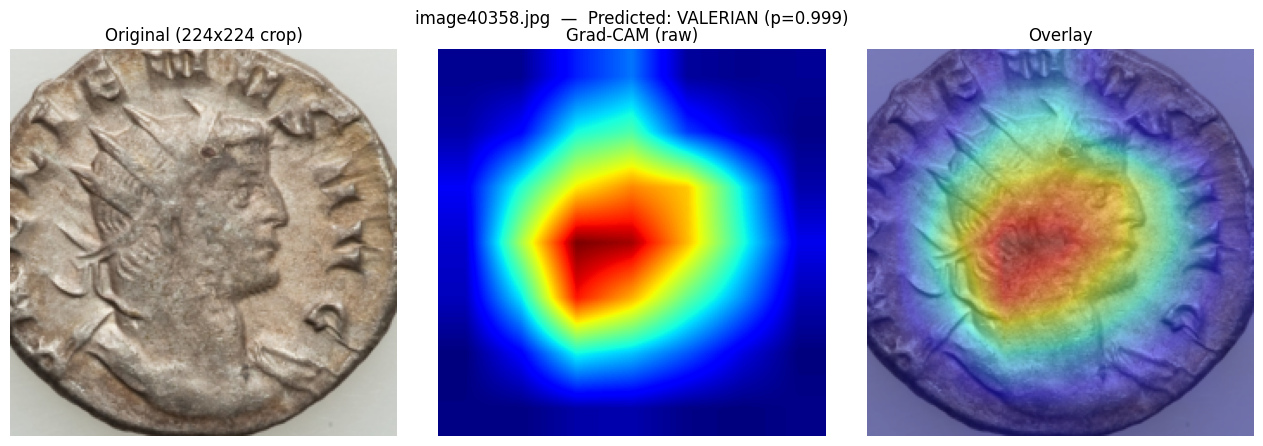

Top predictions:
  VALERIAN               0.999 <-- explained
  GALLIENUS              0.001
  AEMILIAN               0.000


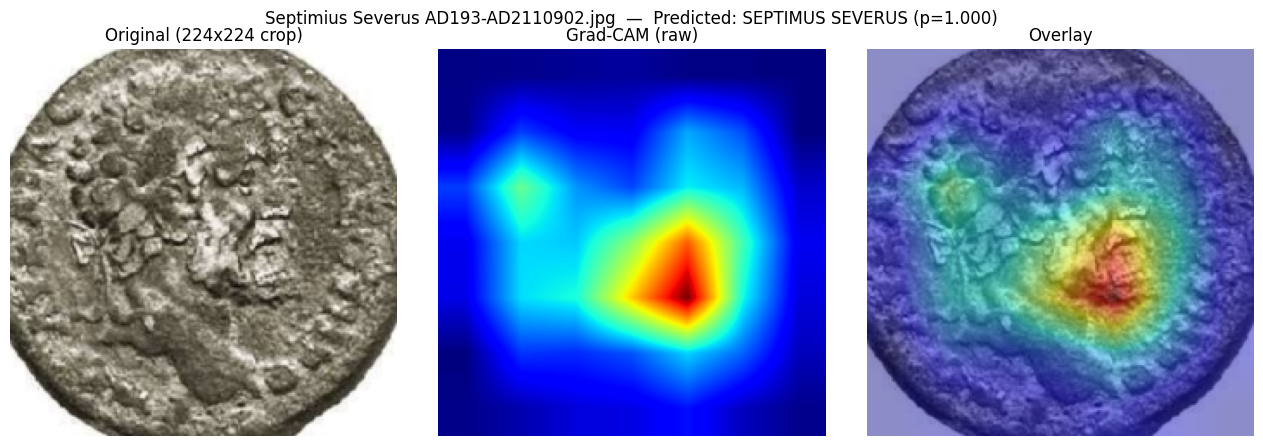

Top predictions:
  SEPTIMUS SEVERUS       1.000 <-- explained
  DIDIUS JULIANUS        0.000
  CONSTANTIUS I          0.000


In [7]:
hard_examples = [
    '41_QUINTILLUS',
    '38_VALERIAN',
    '21_SEPTIMUS SEVERUS',
]

for folder in hard_examples:
    side_a = DATA_DIR / folder / 'side_a'
    if not side_a.exists():
        print(f'skip {folder} (no side_a)'); continue
    img_path = next(side_a.glob('*.jpg'), None) or next(side_a.glob('*.jpeg'), None) or next(side_a.glob('*.png'), None)
    if img_path is None:
        print(f'skip {folder} (no images)'); continue
    visualize(img_path)

## Browse any coin interactively

Pick an emperor and image, optionally force which class the heatmap should
*explain* (leave as "(predicted)" to just see the model's own top guess).

In [8]:
import ipywidgets as widgets
from IPython.display import display, clear_output

emperor_dirs = sorted(
    p.name for p in DATA_DIR.iterdir() if p.is_dir() and (p / 'side_a').exists()
)
image_exts = {'.jpg', '.jpeg', '.png'}

emperor_dd = widgets.Dropdown(options=emperor_dirs, description='Emperor:')
image_dd = widgets.Dropdown(description='Image:')
explain_dd = widgets.Dropdown(
    options=['(predicted)'] + sorted(name_to_idx),
    value='(predicted)',
    description='Explain as:',
)
run_btn = widgets.Button(description='Run Grad-CAM', button_style='primary')
out = widgets.Output()


def refresh_images(*_):
    folder = DATA_DIR / emperor_dd.value / 'side_a'
    imgs = sorted(p.name for p in folder.glob('*') if p.suffix.lower() in image_exts)
    image_dd.options = imgs


def run(_):
    with out:
        clear_output(wait=True)
        path = DATA_DIR / emperor_dd.value / 'side_a' / image_dd.value
        target = None if explain_dd.value == '(predicted)' else explain_dd.value
        visualize(path, target_class=target)


emperor_dd.observe(refresh_images, names='value')
run_btn.on_click(run)
refresh_images()

display(widgets.HBox([emperor_dd, image_dd, explain_dd, run_btn]), out)

Output()